# Phase 17C Strategy Factory Transaction Visuals

This notebook is a static research and paper-watchlist report for Strategy Factory
transaction behaviour. It explains inferred target-weight changes for SPY, QQQ,
BTC-USD, GLD, TLT, and cash.

This is not live trading. It is not broker/API integration. It does not use real
money, does not optimise parameters, and does not promote any candidate.


## Load Data

The notebook reads existing Phase 17A/17B/17C reports plus the transaction
artefacts generated under `reports/strategy_factory/transactions/`.


In [35]:
from pathlib import Path
import sys

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
root = cwd if (cwd / "reports").exists() else cwd.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from scripts.build_strategy_factory_transaction_notebook import (  # noqa: E402
    WATCHLIST_DISPLAY_COLUMNS,
    normalise_watchlist_for_display,
)
ROLLING_3Y_BEAT_RATE_FIELD = "rolling_3y_candidate_beats_spy_pct"

strategy_dir = root / "reports" / "strategy_factory"
transaction_dir = strategy_dir / "transactions"
chart_dir = transaction_dir / "charts"

files = {
    "phase17a_metrics": strategy_dir / "phase17a_strategy_factory_metrics.csv",
    "phase17b_friction": strategy_dir / "phase17b_friction_metrics.csv",
    "phase17b_btc_gap": strategy_dir / "phase17b_btc_weekend_gap_diagnostic.csv",
    "phase17b_rolling": strategy_dir / "phase17b_rolling_relative_summary.csv",
    "phase17c_watchlist": strategy_dir / "watchlist" / "phase17c_watchlist_candidates.csv",
    "watchlist_rolling_snapshot": (
        strategy_dir / "watchlist" / "dashboard" / "watchlist_rolling_snapshot.csv"
    ),
    "transaction_ledger": transaction_dir / "strategy_transaction_ledger.csv",
    "drift_ledger": transaction_dir / "strategy_drift_rebalance_ledger.csv",
    "drift_summary": transaction_dir / "strategy_drift_rebalance_summary.csv",
    "trade_matrix": transaction_dir / "strategy_rebalance_trade_matrix.csv",
    "rebalance_summary": transaction_dir / "strategy_rebalance_summary.csv",
    "turnover_timeline": transaction_dir / "strategy_turnover_timeline.csv",
    "allocation_long": transaction_dir / "strategy_asset_allocation_long.csv",
    "latest_allocations": transaction_dir / "strategy_latest_allocations.csv",
}
pd.DataFrame(
    [{"name": name, "path": str(path), "exists": path.exists()} for name, path in files.items()]
)


,name,path,exists
0,phase17a_metrics,C:\Users\Devesh Pansare\Desktop\Personal_Proje...,True
1,phase17b_friction,C:\Users\Devesh Pansare\Desktop\Personal_Proje...,True
2,phase17b_btc_gap,C:\Users\Devesh Pansare\Desktop\Personal_Proje...,True
3,phase17b_rolling,C:\Users\Devesh Pansare\Desktop\Personal_Proje...,True
4,phase17c_watchlist,C:\Users\Devesh Pansare\Desktop\Personal_Proje...,True
5,watchlist_rolling_snapshot,C:\Users\Devesh Pansare\Desktop\Personal_Proje...,True
6,transaction_ledger,C:\Users\Devesh Pansare\Desktop\Personal_Proje...,True
7,drift_ledger,C:\Users\Devesh Pansare\Desktop\Personal_Proje...,True
8,drift_summary,C:\Users\Devesh Pansare\Desktop\Personal_Proje...,True
9,trade_matrix,C:\Users\Devesh Pansare\Desktop\Personal_Proje...,True


In [36]:
metrics = pd.read_csv(files["phase17a_metrics"])
friction = pd.read_csv(files["phase17b_friction"])
btc_gap = pd.read_csv(files["phase17b_btc_gap"])
watchlist = pd.read_csv(files["phase17c_watchlist"])
watchlist_rolling = (
    pd.read_csv(files["watchlist_rolling_snapshot"])
    if files["watchlist_rolling_snapshot"].exists()
    else pd.DataFrame()
)
phase17b_rolling = (
    pd.read_csv(files["phase17b_rolling"])
    if files["phase17b_rolling"].exists()
    else pd.DataFrame()
)
ledger = pd.read_csv(files["transaction_ledger"])
drift_ledger = pd.read_csv(files["drift_ledger"])
drift_summary = pd.read_csv(files["drift_summary"])
trade_matrix = pd.read_csv(files["trade_matrix"])
summary = pd.read_csv(files["rebalance_summary"])
turnover = pd.read_csv(files["turnover_timeline"])
allocation = pd.read_csv(files["allocation_long"])
latest_allocations = pd.read_csv(files["latest_allocations"])

watchlist_ids = watchlist["candidate_id"].astype(str).tolist()
watchlist_enriched, missing_watchlist_display_cols = normalise_watchlist_for_display(
    watchlist,
    watchlist_rolling=watchlist_rolling,
    phase17b_rolling=phase17b_rolling,
)
all_strategy_ids = sorted(allocation["strategy_id"].astype(str).unique())
watchlist_ids


['sf_spy_core_phase6_overlay_satellite_qqq',
 'sf_spy_qqq_60_40_monthly_rebalanced',
 'sf_spy_qqq_btc_capped_offensive']

## Strategy Explanation

- `sf_spy_buy_hold`: holds 100% SPY.
- `sf_spy_qqq_60_40_monthly_rebalanced`: targets 60% SPY and 40% QQQ with monthly rebalancing.
- `sf_spy_qqq_tactical_momentum`: chooses SPY or QQQ using a fixed trailing momentum rule, with cash when both are negative.
- `sf_spy_qqq_gld_tlt_risk_off_rotation`: rotates between SPY/QQQ risk-on exposure and GLD/TLT/cash risk-off exposure.
- `sf_spy_core_phase6_overlay_satellite_qqq`: links a SPY overlay-style core to a capped QQQ satellite when risk-on.
- `sf_spy_qqq_btc_capped_offensive`: holds an SPY/QQQ base with a capped BTC sleeve when BTC momentum and SPY risk-on conditions are positive.


## Performance Overview

These tables and charts describe research performance only. They are not
promotion decisions and do not alter the current operational paper baseline.


In [37]:
overview_cols = [
    "strategy",
    "end_value",
    "total_return_pct",
    "cagr_pct",
    "volatility_pct",
    "max_drawdown_pct",
    "calmar",
]
metrics[overview_cols].sort_values("end_value", ascending=False)


,strategy,end_value,total_return_pct,cagr_pct,volatility_pct,max_drawdown_pct,calmar
5,sf_spy_qqq_btc_capped_offensive,85638.57,756.39,20.10,19.48,-31.40,0.640
1,sf_spy_qqq_60_40_monthly_rebalanced,57072.27,470.72,16.02,18.89,-31.40,0.510
4,sf_spy_core_phase6_overlay_satellite_qqq,57072.27,470.72,16.02,18.89,-31.40,0.510
0,sf_spy_buy_hold,45205.47,352.05,13.73,17.55,-33.72,0.407
2,sf_spy_qqq_tactical_momentum,35998.81,259.99,11.55,17.65,-28.56,0.404
3,sf_spy_qqq_gld_tlt_risk_off_rotation,20785.25,107.85,6.44,15.67,-29.09,0.221


In [38]:
plot_frame = metrics.set_index("strategy")[["end_value", "cagr_pct", "max_drawdown_pct", "calmar"]]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, column in zip(axes.ravel(), plot_frame.columns):
    plot_frame[column].sort_values().plot(kind="barh", ax=ax)
    ax.set_title(column)
    ax.grid(True, axis="x", alpha=0.25)
fig.tight_layout()
plt.show()


C:\Users\Devesh Pansare\AppData\Local\Temp\ipykernel_67884\688744970.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Allocation Timelines

The Strategy Factory transaction ledger is inferred from target allocation changes.
These are not broker fills.


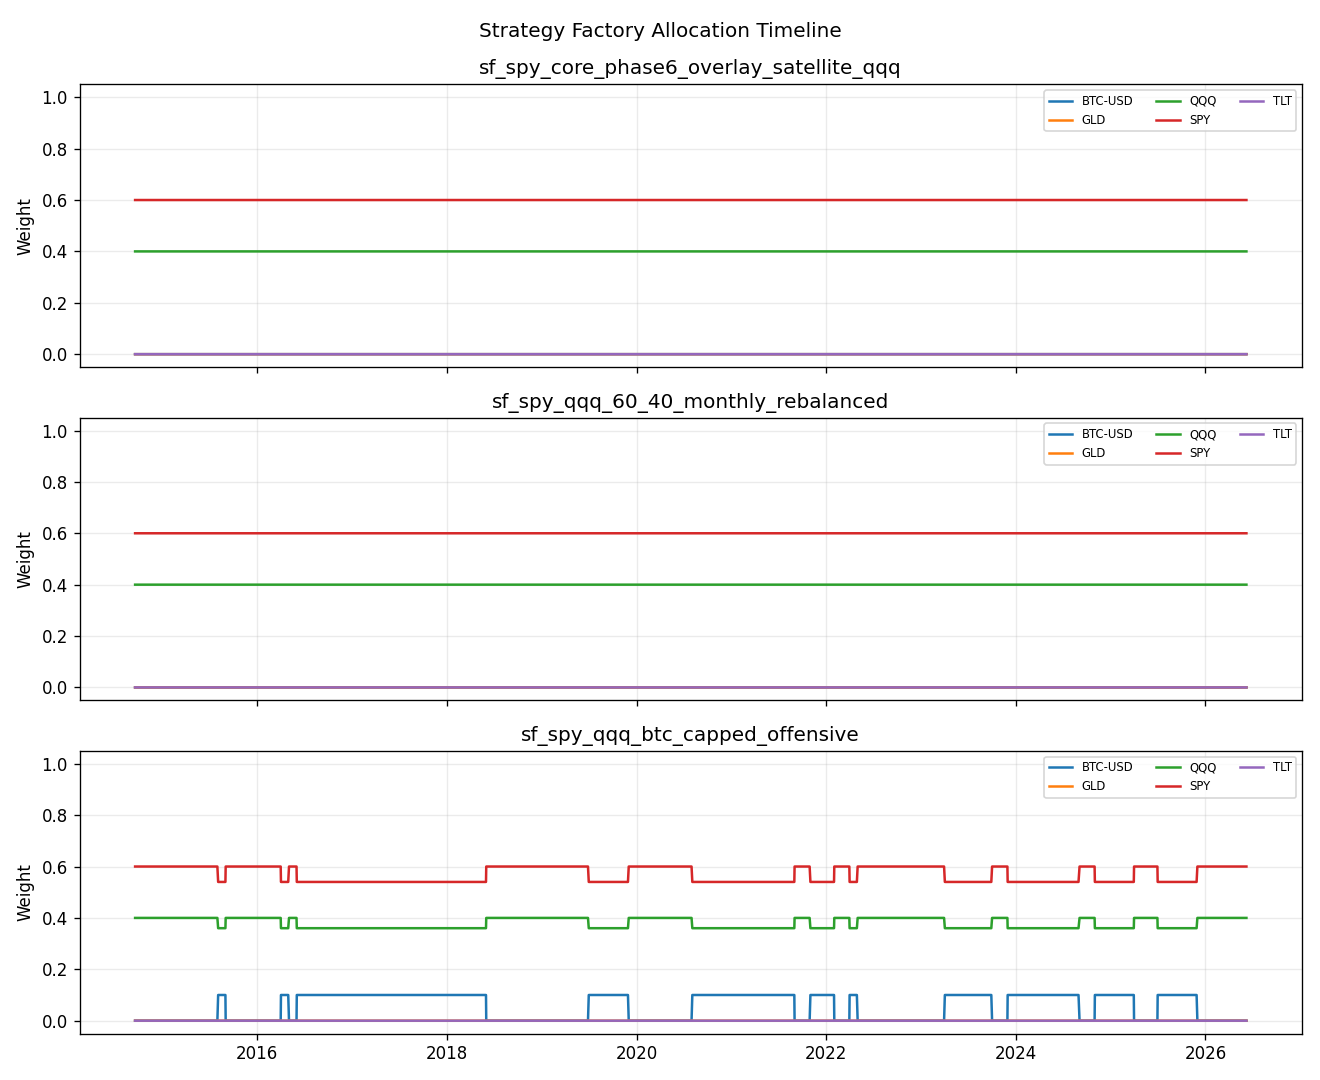

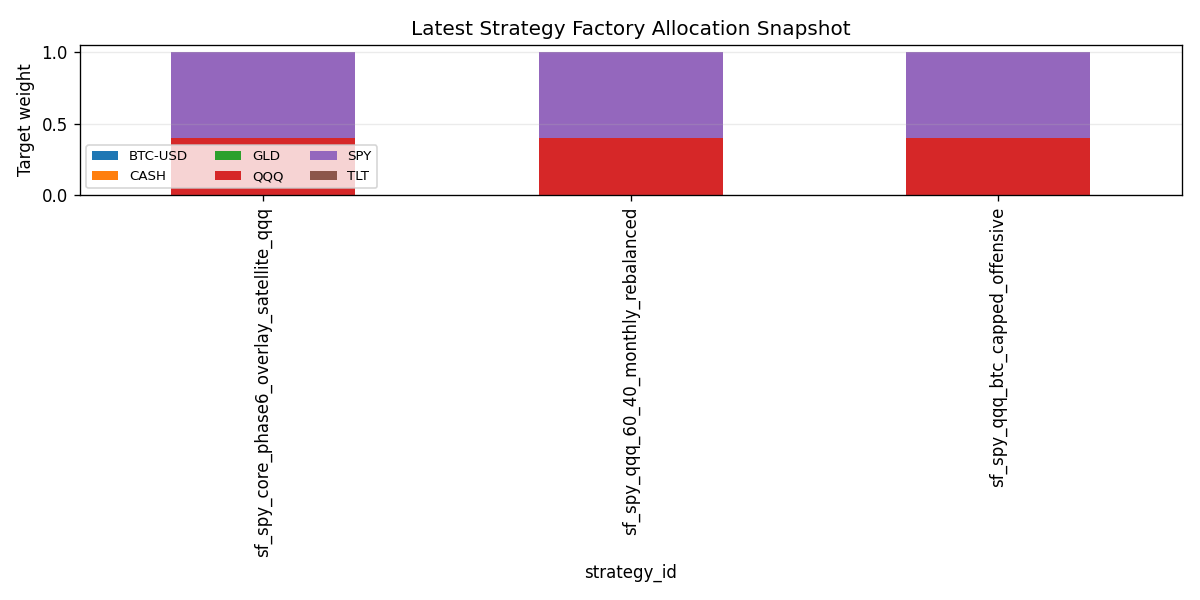

In [39]:
display(Image(filename=str(chart_dir / "allocation_timeline_by_strategy.png")))
display(Image(filename=str(chart_dir / "latest_allocation_snapshot.png")))


In [40]:
allocation.loc[
    allocation["strategy_id"].isin(watchlist_ids),
    ["date", "strategy_id", "asset", "weight"],
].tail(30)


,date,strategy_id,asset,weight
70722,2026-06-02,sf_spy_qqq_btc_capped_offensive,BTC-USD,0.0
70723,2026-06-02,sf_spy_qqq_btc_capped_offensive,CASH,0.0
70724,2026-06-02,sf_spy_qqq_btc_capped_offensive,GLD,0.0
70725,2026-06-02,sf_spy_qqq_btc_capped_offensive,QQQ,0.4
70726,2026-06-02,sf_spy_qqq_btc_capped_offensive,SPY,0.6
70727,2026-06-02,sf_spy_qqq_btc_capped_offensive,TLT,0.0
70728,2026-06-03,sf_spy_qqq_btc_capped_offensive,BTC-USD,0.0
70729,2026-06-03,sf_spy_qqq_btc_capped_offensive,CASH,0.0
70730,2026-06-03,sf_spy_qqq_btc_capped_offensive,GLD,0.0
70731,2026-06-03,sf_spy_qqq_btc_capped_offensive,QQQ,0.4


## Target-weight changes vs actual rebalance trades

The target-weight ledger shows signal or allocation changes. For example, the BTC
capped strategy has explicit BTC entries and exits when the target BTC sleeve moves
between 0% and 10%.

The drift-rebalance ledger estimates implementation trades. It lets current weights
drift with asset returns between rebalance dates, then calculates the trades needed to
restore the strategy target. This makes constant-target strategies like SPY/QQQ 60/40
visible: even if the target stays 60/40, market returns push the actual portfolio away
from 60/40 and monthly rebalancing creates buy/sell trades.


In [41]:
target_change_rows = ledger.groupby("strategy_id").size().rename("target_change_rows")
drift_rows = drift_ledger.groupby("strategy_id").size().rename("drift_rebalance_rows")
pd.concat([target_change_rows, drift_rows], axis=1).fillna(0).astype(int)


,target_change_rows,drift_rebalance_rows
strategy_id,,
sf_spy_buy_hold,1,0
sf_spy_core_phase6_overlay_satellite_qqq,2,282
sf_spy_qqq_60_40_monthly_rebalanced,2,282
sf_spy_qqq_btc_capped_offensive,68,366
sf_spy_qqq_gld_tlt_risk_off_rotation,92,251
sf_spy_qqq_tactical_momentum,73,72


## Transaction Ledger

The ledger shows inferred BUY_ENTRY, BUY_INCREASE, SELL_REDUCE, SELL_EXIT, and
CASH_ALLOCATION_CHANGE rows. Notional changes use a $10,000 interpretation baseline.


In [42]:
ledger.head(50)


,strategy_id,rebalance_date,asset,previous_weight,target_weight,weight_change,transaction_direction,transaction_type,estimated_notional_change_per_10000,turnover_contribution,is_buy,is_sell,is_rebalance,is_entry,is_exit,transaction_data_available,notes
0,sf_spy_buy_hold,2014-09-17,SPY,0.00,1.00,1.00,BUY_ENTRY,target_weight_change,10000.0,1.00,True,False,True,True,False,True,Inferred from target allocation weight change;...
1,sf_spy_core_phase6_overlay_satellite_qqq,2014-09-17,QQQ,0.00,0.40,0.40,BUY_ENTRY,target_weight_change,4000.0,0.40,True,False,True,True,False,True,Inferred from target allocation weight change;...
2,sf_spy_core_phase6_overlay_satellite_qqq,2014-09-17,SPY,0.00,0.60,0.60,BUY_ENTRY,target_weight_change,6000.0,0.60,True,False,True,True,False,True,Inferred from target allocation weight change;...
3,sf_spy_qqq_60_40_monthly_rebalanced,2014-09-17,QQQ,0.00,0.40,0.40,BUY_ENTRY,target_weight_change,4000.0,0.40,True,False,True,True,False,True,Inferred from target allocation weight change;...
4,sf_spy_qqq_60_40_monthly_rebalanced,2014-09-17,SPY,0.00,0.60,0.60,BUY_ENTRY,target_weight_change,6000.0,0.60,True,False,True,True,False,True,Inferred from target allocation weight change;...
5,sf_spy_qqq_btc_capped_offensive,2014-09-17,QQQ,0.00,0.40,0.40,BUY_ENTRY,target_weight_change,4000.0,0.40,True,False,True,True,False,True,Inferred from target allocation weight change;...
6,sf_spy_qqq_btc_capped_offensive,2014-09-17,SPY,0.00,0.60,0.60,BUY_ENTRY,target_weight_change,6000.0,0.60,True,False,True,True,False,True,Inferred from target allocation weight change;...
7,sf_spy_qqq_btc_capped_offensive,2015-08-03,BTC-USD,0.00,0.10,0.10,BUY_ENTRY,target_weight_change,1000.0,0.10,True,False,True,True,False,True,Inferred from target allocation weight change;...
8,sf_spy_qqq_btc_capped_offensive,2015-08-03,QQQ,0.40,0.36,-0.04,SELL_REDUCE,target_weight_change,-400.0,0.04,False,True,True,False,False,True,Inferred from target allocation weight change;...
9,sf_spy_qqq_btc_capped_offensive,2015-08-03,SPY,0.60,0.54,-0.06,SELL_REDUCE,target_weight_change,-600.0,0.06,False,True,True,False,False,True,Inferred from target allocation weight change;...


In [43]:
ledger.tail(50)


,strategy_id,rebalance_date,asset,previous_weight,target_weight,weight_change,transaction_direction,transaction_type,estimated_notional_change_per_10000,turnover_contribution,is_buy,is_sell,is_rebalance,is_entry,is_exit,transaction_data_available,notes
188,sf_spy_qqq_tactical_momentum,2018-12-03,QQQ,1.0,0.0,-1.0,SELL_EXIT,target_weight_change,-10000.0,1.0,False,True,True,False,True,True,Inferred from target allocation weight change;...
189,sf_spy_qqq_tactical_momentum,2018-12-03,SPY,0.0,1.0,1.0,BUY_ENTRY,target_weight_change,10000.0,1.0,True,False,True,True,False,True,Inferred from target allocation weight change;...
190,sf_spy_qqq_tactical_momentum,2019-01-02,CASH,0.0,1.0,1.0,CASH_ALLOCATION_CHANGE,cash_allocation_change,10000.0,1.0,False,False,True,False,False,True,Inferred from target allocation weight change;...
191,sf_spy_qqq_tactical_momentum,2019-01-02,SPY,1.0,0.0,-1.0,SELL_EXIT,target_weight_change,-10000.0,1.0,False,True,True,False,True,True,Inferred from target allocation weight change;...
192,sf_spy_qqq_tactical_momentum,2019-05-01,CASH,1.0,0.0,-1.0,CASH_ALLOCATION_CHANGE,cash_allocation_change,-10000.0,1.0,False,False,True,False,False,True,Inferred from target allocation weight change;...
193,sf_spy_qqq_tactical_momentum,2019-05-01,QQQ,0.0,1.0,1.0,BUY_ENTRY,target_weight_change,10000.0,1.0,True,False,True,True,False,True,Inferred from target allocation weight change;...
194,sf_spy_qqq_tactical_momentum,2019-10-01,QQQ,1.0,0.0,-1.0,SELL_EXIT,target_weight_change,-10000.0,1.0,False,True,True,False,True,True,Inferred from target allocation weight change;...
195,sf_spy_qqq_tactical_momentum,2019-10-01,SPY,0.0,1.0,1.0,BUY_ENTRY,target_weight_change,10000.0,1.0,True,False,True,True,False,True,Inferred from target allocation weight change;...
196,sf_spy_qqq_tactical_momentum,2019-12-02,QQQ,0.0,1.0,1.0,BUY_ENTRY,target_weight_change,10000.0,1.0,True,False,True,True,False,True,Inferred from target allocation weight change;...
197,sf_spy_qqq_tactical_momentum,2019-12-02,SPY,1.0,0.0,-1.0,SELL_EXIT,target_weight_change,-10000.0,1.0,False,True,True,False,True,True,Inferred from target allocation weight change;...


In [44]:
by_strategy = ledger.groupby("strategy_id").size().rename("transaction_rows")
by_asset = ledger.groupby("asset").size().rename("transaction_rows")
buy_sell = ledger.groupby(["strategy_id", "transaction_direction"]).size().unstack(fill_value=0)
by_strategy, by_asset, buy_sell


(strategy_id
 sf_spy_buy_hold                              1
 sf_spy_core_phase6_overlay_satellite_qqq     2
 sf_spy_qqq_60_40_monthly_rebalanced          2
 sf_spy_qqq_btc_capped_offensive             68
 sf_spy_qqq_gld_tlt_risk_off_rotation        92
 sf_spy_qqq_tactical_momentum                73
 Name: transaction_rows, dtype: int64,
 asset
 BTC-USD    22
 CASH       32
 GLD        18
 QQQ        71
 SPY        83
 TLT        12
 Name: transaction_rows, dtype: int64,
 transaction_direction                     BUY_ENTRY  BUY_INCREASE  \
 strategy_id                                                         
 sf_spy_buy_hold                                   1             0   
 sf_spy_core_phase6_overlay_satellite_qqq          2             0   
 sf_spy_qqq_60_40_monthly_rebalanced               2             0   
 sf_spy_qqq_btc_capped_offensive                  13            22   
 sf_spy_qqq_gld_tlt_risk_off_rotation             40             1   
 sf_spy_qqq_tactical_momentum     

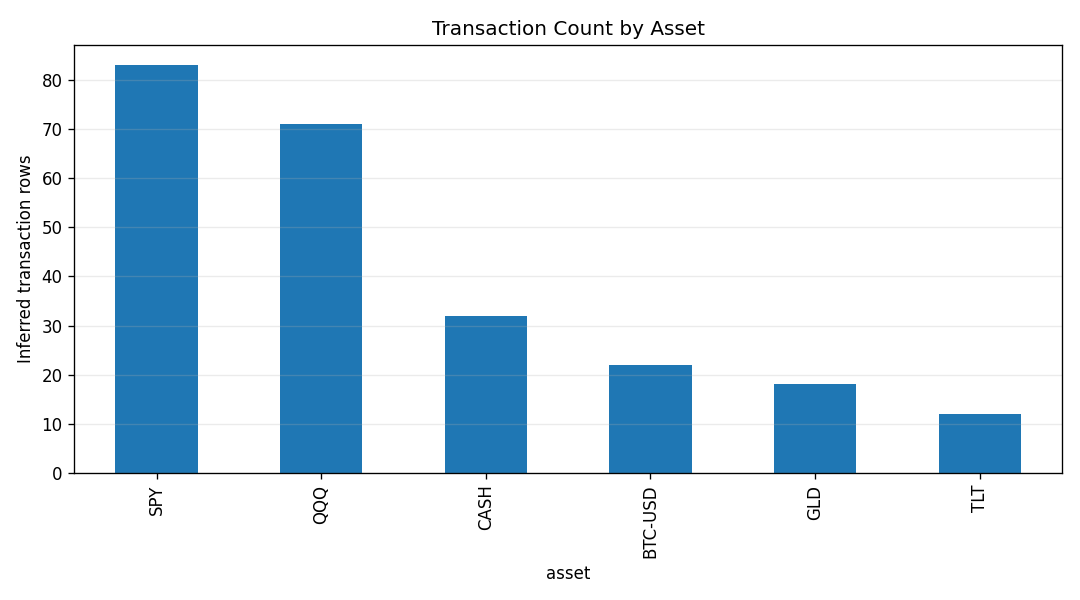

In [45]:
display(Image(filename=str(chart_dir / "transaction_count_by_asset.png")))


## Drift-based Rebalance Ledger

These rows estimate the trades needed to restore target weights after asset returns
cause holdings to drift. They are implementation estimates, not fills.


In [46]:
drift_ledger.head(50)


,strategy_id,rebalance_date,asset,pre_rebalance_weight,target_weight,weight_change_required,transaction_direction,estimated_trade_notional_per_10000,is_buy,is_sell,is_drift_rebalance,drift_rebalance_available,blocking_reason,notes
0,sf_spy_core_phase6_overlay_satellite_qqq,2014-10-01,SPY,0.598433,0.6,0.001567,BUY_TO_TARGET,15.67,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
1,sf_spy_core_phase6_overlay_satellite_qqq,2014-10-01,QQQ,0.401567,0.4,-0.001567,SELL_TO_TARGET,-15.67,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
2,sf_spy_core_phase6_overlay_satellite_qqq,2014-11-03,SPY,0.598154,0.6,0.001846,BUY_TO_TARGET,18.46,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
3,sf_spy_core_phase6_overlay_satellite_qqq,2014-11-03,QQQ,0.401846,0.4,-0.001846,SELL_TO_TARGET,-18.46,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
4,sf_spy_core_phase6_overlay_satellite_qqq,2014-12-01,SPY,0.597468,0.6,0.002532,BUY_TO_TARGET,25.32,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
5,sf_spy_core_phase6_overlay_satellite_qqq,2014-12-01,QQQ,0.402532,0.4,-0.002532,SELL_TO_TARGET,-25.32,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
6,sf_spy_core_phase6_overlay_satellite_qqq,2015-01-02,SPY,0.604356,0.6,-0.004356,SELL_TO_TARGET,-43.56,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
7,sf_spy_core_phase6_overlay_satellite_qqq,2015-01-02,QQQ,0.395644,0.4,0.004356,BUY_TO_TARGET,43.56,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
8,sf_spy_core_phase6_overlay_satellite_qqq,2015-02-02,SPY,0.598111,0.6,0.001889,BUY_TO_TARGET,18.89,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
9,sf_spy_core_phase6_overlay_satellite_qqq,2015-02-02,QQQ,0.401889,0.4,-0.001889,SELL_TO_TARGET,-18.89,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...


In [47]:
drift_ledger.tail(50)


,strategy_id,rebalance_date,asset,pre_rebalance_weight,target_weight,weight_change_required,transaction_direction,estimated_trade_notional_per_10000,is_buy,is_sell,is_drift_rebalance,drift_rebalance_available,blocking_reason,notes
1203,sf_spy_qqq_tactical_momentum,2018-12-03,SPY,0.0,1.0,1.0,BUY_TO_TARGET,10000.0,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
1204,sf_spy_qqq_tactical_momentum,2018-12-03,QQQ,1.0,0.0,-1.0,SELL_TO_TARGET,-10000.0,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
1205,sf_spy_qqq_tactical_momentum,2019-01-02,SPY,1.0,0.0,-1.0,SELL_TO_TARGET,-10000.0,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
1206,sf_spy_qqq_tactical_momentum,2019-01-02,CASH,0.0,1.0,1.0,CASH_REBALANCE_CHANGE,10000.0,False,False,True,True,NaN,Estimated drift rebalance from asset returns a...
1207,sf_spy_qqq_tactical_momentum,2019-05-01,QQQ,0.0,1.0,1.0,BUY_TO_TARGET,10000.0,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
1208,sf_spy_qqq_tactical_momentum,2019-05-01,CASH,1.0,0.0,-1.0,CASH_REBALANCE_CHANGE,-10000.0,False,False,True,True,NaN,Estimated drift rebalance from asset returns a...
1209,sf_spy_qqq_tactical_momentum,2019-10-01,SPY,0.0,1.0,1.0,BUY_TO_TARGET,10000.0,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
1210,sf_spy_qqq_tactical_momentum,2019-10-01,QQQ,1.0,0.0,-1.0,SELL_TO_TARGET,-10000.0,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
1211,sf_spy_qqq_tactical_momentum,2019-12-02,SPY,1.0,0.0,-1.0,SELL_TO_TARGET,-10000.0,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
1212,sf_spy_qqq_tactical_momentum,2019-12-02,QQQ,0.0,1.0,1.0,BUY_TO_TARGET,10000.0,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...


In [48]:
drift_summary.sort_values("rebalance_trade_rows", ascending=False)


,strategy_id,rebalance_trade_rows,rebalance_dates,first_rebalance_date,latest_rebalance_date,buy_rows,sell_rows,cash_change_rows,total_abs_trade_notional_per_10000,total_turnover_required,drift_rebalance_available,blocking_reason
3,sf_spy_qqq_btc_capped_offensive,366,141,2014-10-01,2026-06-01,187,179,0,67777.99,6.777797,True,NaN
1,sf_spy_core_phase6_overlay_satellite_qqq,282,141,2014-10-01,2026-06-01,141,141,0,12237.40,1.223739,True,NaN
2,sf_spy_qqq_60_40_monthly_rebalanced,282,141,2014-10-01,2026-06-01,141,141,0,12237.40,1.223739,True,NaN
4,sf_spy_qqq_gld_tlt_risk_off_rotation,251,116,2014-10-01,2026-06-01,120,119,12,706647.74,70.664781,True,NaN
5,sf_spy_qqq_tactical_momentum,72,36,2014-10-01,2026-05-01,26,26,20,720000.00,72.000000,True,NaN
0,sf_spy_buy_hold,0,0,NaN,NaN,0,0,0,0.00,0.000000,True,NaN


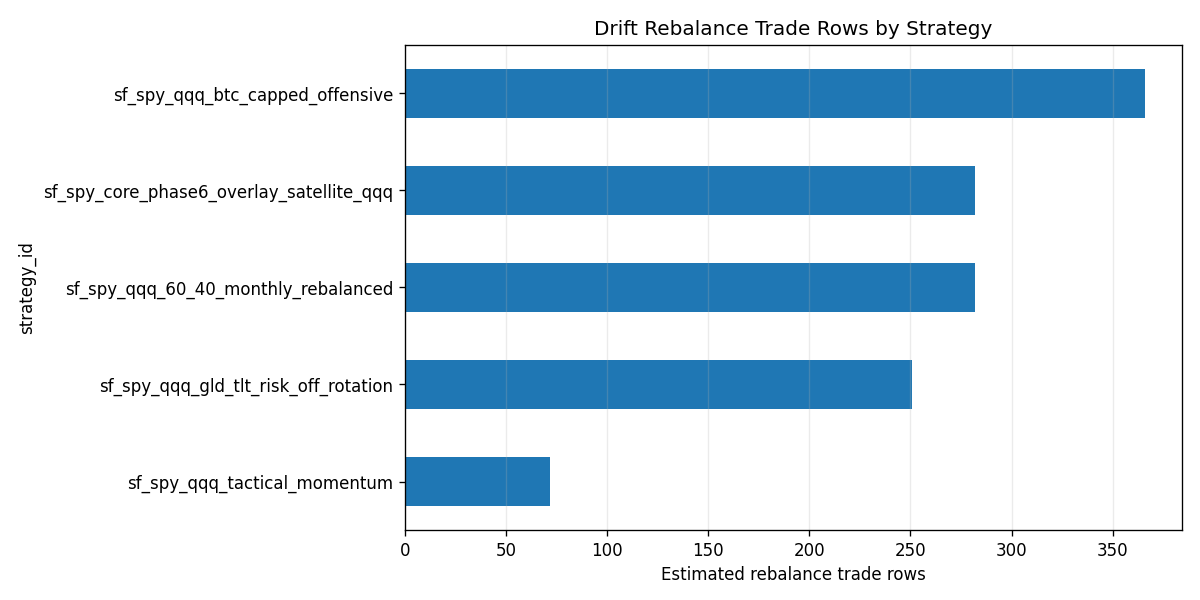

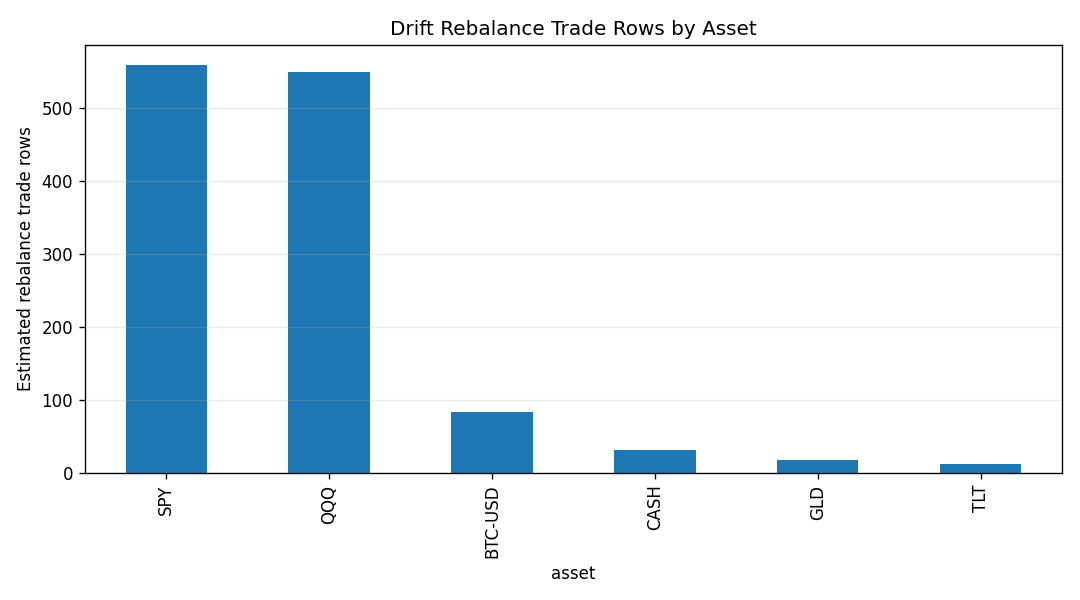

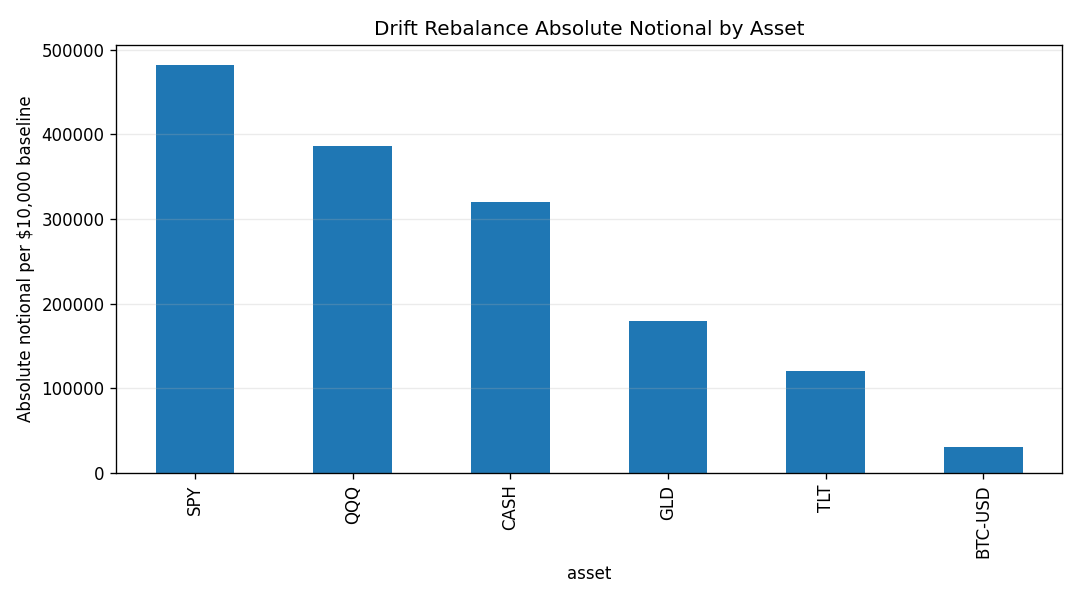

In [49]:
display(Image(filename=str(chart_dir / "drift_rebalance_trades_by_strategy.png")))
display(Image(filename=str(chart_dir / "drift_rebalance_trades_by_asset.png")))
display(Image(filename=str(chart_dir / "drift_rebalance_notional_by_asset.png")))


## SPY/QQQ 60/40 Rebalance Inspection

This section shows the monthly implementation trades for the constant-target 60/40
candidate. Positive notional buys an asset back to target; negative notional sells an
overweight asset back to target.


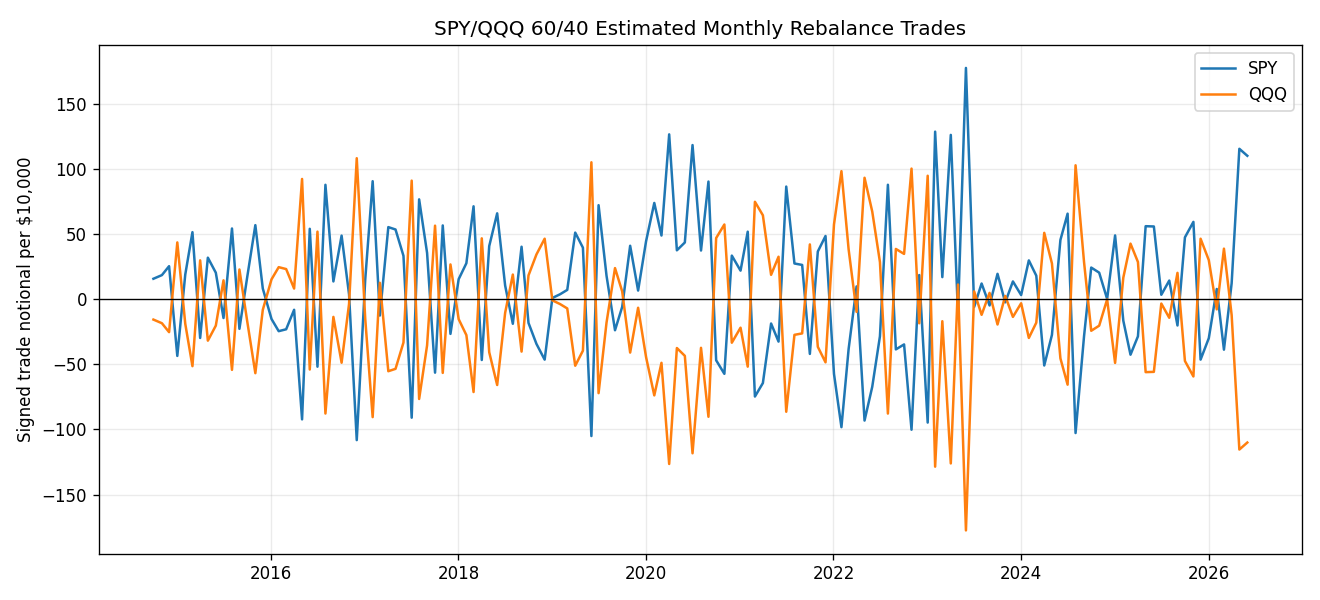

,strategy_id,rebalance_date,asset,pre_rebalance_weight,target_weight,weight_change_required,transaction_direction,estimated_trade_notional_per_10000,is_buy,is_sell,is_drift_rebalance,drift_rebalance_available,blocking_reason,notes
534,sf_spy_qqq_60_40_monthly_rebalanced,2025-04-01,SPY,0.602853,0.6,-0.002853,SELL_TO_TARGET,-28.53,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
535,sf_spy_qqq_60_40_monthly_rebalanced,2025-04-01,QQQ,0.397147,0.4,0.002853,BUY_TO_TARGET,28.53,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
536,sf_spy_qqq_60_40_monthly_rebalanced,2025-05-01,SPY,0.594399,0.6,0.005601,BUY_TO_TARGET,56.01,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
537,sf_spy_qqq_60_40_monthly_rebalanced,2025-05-01,QQQ,0.405601,0.4,-0.005601,SELL_TO_TARGET,-56.01,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
538,sf_spy_qqq_60_40_monthly_rebalanced,2025-06-02,SPY,0.594420,0.6,0.005580,BUY_TO_TARGET,55.80,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
539,sf_spy_qqq_60_40_monthly_rebalanced,2025-06-02,QQQ,0.405580,0.4,-0.005580,SELL_TO_TARGET,-55.80,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
540,sf_spy_qqq_60_40_monthly_rebalanced,2025-07-01,SPY,0.599664,0.6,0.000336,BUY_TO_TARGET,3.36,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
541,sf_spy_qqq_60_40_monthly_rebalanced,2025-07-01,QQQ,0.400336,0.4,-0.000336,SELL_TO_TARGET,-3.36,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...
542,sf_spy_qqq_60_40_monthly_rebalanced,2025-08-01,SPY,0.598571,0.6,0.001429,BUY_TO_TARGET,14.29,True,False,True,True,NaN,Estimated drift rebalance from asset returns a...
543,sf_spy_qqq_60_40_monthly_rebalanced,2025-08-01,QQQ,0.401429,0.4,-0.001429,SELL_TO_TARGET,-14.29,False,True,True,True,NaN,Estimated drift rebalance from asset returns a...


In [50]:
strategy_6040 = "sf_spy_qqq_60_40_monthly_rebalanced"
trades_6040 = drift_ledger[
    (drift_ledger["strategy_id"] == strategy_6040)
    & (drift_ledger["asset"].isin(["SPY", "QQQ"]))
].copy()
display(Image(filename=str(chart_dir / "spy_qqq_60_40_rebalance_timeline.png")))
trades_6040.tail(30)


## BTC Capped Rebalance Inspection

BTC entries and exits appear in the target-change ledger. Regular rebalance trades while
BTC is active appear in the drift ledger.


In [51]:
btc_target_changes = ledger[
    (ledger["strategy_id"] == "sf_spy_qqq_btc_capped_offensive")
    & (ledger["asset"] == "BTC-USD")
].copy()
btc_drift_trades = drift_ledger[
    (drift_ledger["strategy_id"] == "sf_spy_qqq_btc_capped_offensive")
    & (drift_ledger["asset"] == "BTC-USD")
].copy()
btc_target_changes.tail(20), btc_drift_trades.tail(20)


(                        strategy_id rebalance_date    asset  previous_weight  \
 13  sf_spy_qqq_btc_capped_offensive     2016-04-01  BTC-USD              0.0   
 16  sf_spy_qqq_btc_capped_offensive     2016-05-02  BTC-USD              0.1   
 19  sf_spy_qqq_btc_capped_offensive     2016-06-01  BTC-USD              0.0   
 22  sf_spy_qqq_btc_capped_offensive     2018-06-01  BTC-USD              0.1   
 25  sf_spy_qqq_btc_capped_offensive     2019-07-01  BTC-USD              0.0   
 28  sf_spy_qqq_btc_capped_offensive     2019-12-02  BTC-USD              0.1   
 31  sf_spy_qqq_btc_capped_offensive     2020-08-03  BTC-USD              0.0   
 34  sf_spy_qqq_btc_capped_offensive     2021-09-01  BTC-USD              0.1   
 37  sf_spy_qqq_btc_capped_offensive     2021-11-01  BTC-USD              0.0   
 40  sf_spy_qqq_btc_capped_offensive     2022-02-01  BTC-USD              0.1   
 43  sf_spy_qqq_btc_capped_offensive     2022-04-01  BTC-USD              0.0   
 46  sf_spy_qqq_btc_capped_o

## Trade Burden Comparison

This compares which strategies and assets create the most estimated implementation
activity.


In [52]:
trade_matrix.sort_values("total_abs_trade_notional_per_10000", ascending=False).head(25)


,strategy_id,asset,rebalance_trade_rows,buy_rows,sell_rows,total_signed_trade_notional_per_10000,total_abs_trade_notional_per_10000
14,sf_spy_qqq_tactical_momentum,SPY,27,13,14,-10000.00,270000.00
13,sf_spy_qqq_tactical_momentum,QQQ,25,13,12,10000.00,250000.00
12,sf_spy_qqq_tactical_momentum,CASH,20,0,0,0.00,200000.00
8,sf_spy_qqq_gld_tlt_risk_off_rotation,GLD,18,9,9,0.00,180000.00
10,sf_spy_qqq_gld_tlt_risk_off_rotation,SPY,108,63,45,-4573.93,178656.15
7,sf_spy_qqq_gld_tlt_risk_off_rotation,CASH,12,0,0,0.00,120000.00
11,sf_spy_qqq_gld_tlt_risk_off_rotation,TLT,12,6,6,0.00,120000.00
9,sf_spy_qqq_gld_tlt_risk_off_rotation,QQQ,101,42,59,4573.93,107991.59
4,sf_spy_qqq_btc_capped_offensive,BTC-USD,84,38,46,-2221.33,30796.93
6,sf_spy_qqq_btc_capped_offensive,SPY,141,82,59,2689.86,20678.22


## Turnover Visualisation

Turnover is the sum of absolute target-weight changes by strategy and rebalance date.
Large spikes identify periods where the candidate changed exposure materially.


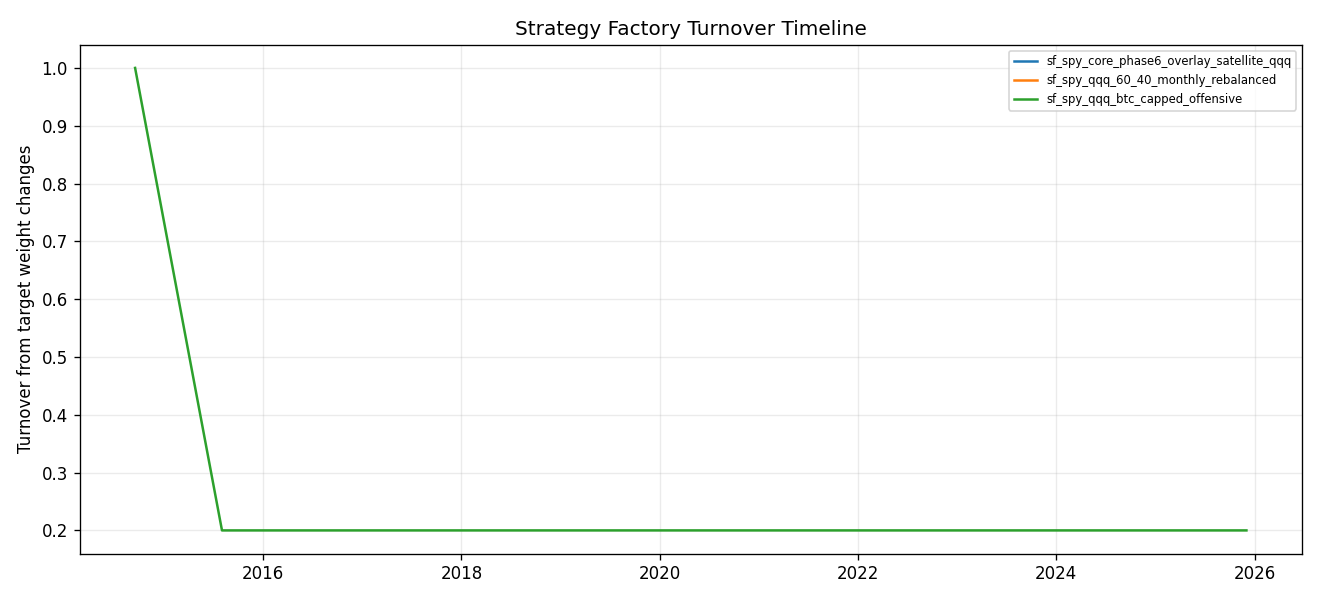

,strategy_id,rebalance_date,turnover,transaction_rows,buy_rows,sell_rows
31,sf_spy_qqq_gld_tlt_risk_off_rotation,2015-09-01,2.0,3,0,2
30,sf_spy_qqq_gld_tlt_risk_off_rotation,2015-08-03,2.0,3,2,0
29,sf_spy_qqq_gld_tlt_risk_off_rotation,2015-07-01,2.0,2,0,1
28,sf_spy_qqq_gld_tlt_risk_off_rotation,2015-04-01,2.0,2,1,0
27,sf_spy_qqq_gld_tlt_risk_off_rotation,2014-10-01,2.0,2,0,1
33,sf_spy_qqq_gld_tlt_risk_off_rotation,2016-03-01,2.0,2,1,1
34,sf_spy_qqq_gld_tlt_risk_off_rotation,2016-04-01,2.0,3,2,1
35,sf_spy_qqq_gld_tlt_risk_off_rotation,2016-05-02,2.0,3,1,2
32,sf_spy_qqq_gld_tlt_risk_off_rotation,2015-11-02,2.0,2,1,0
62,sf_spy_qqq_gld_tlt_risk_off_rotation,2026-05-01,2.0,3,2,1


In [53]:
display(Image(filename=str(chart_dir / "turnover_timeline_by_strategy.png")))
high_turnover = turnover.sort_values("turnover", ascending=False).head(25)
high_turnover


## BTC-Specific Inspection

BTC strategy returns are evaluated on ETF-common trading dates in the Strategy Factory
frame. BTC weekend observations and weekend gap risk are diagnostic context and are not
directly represented in ETF-common-date strategy returns.


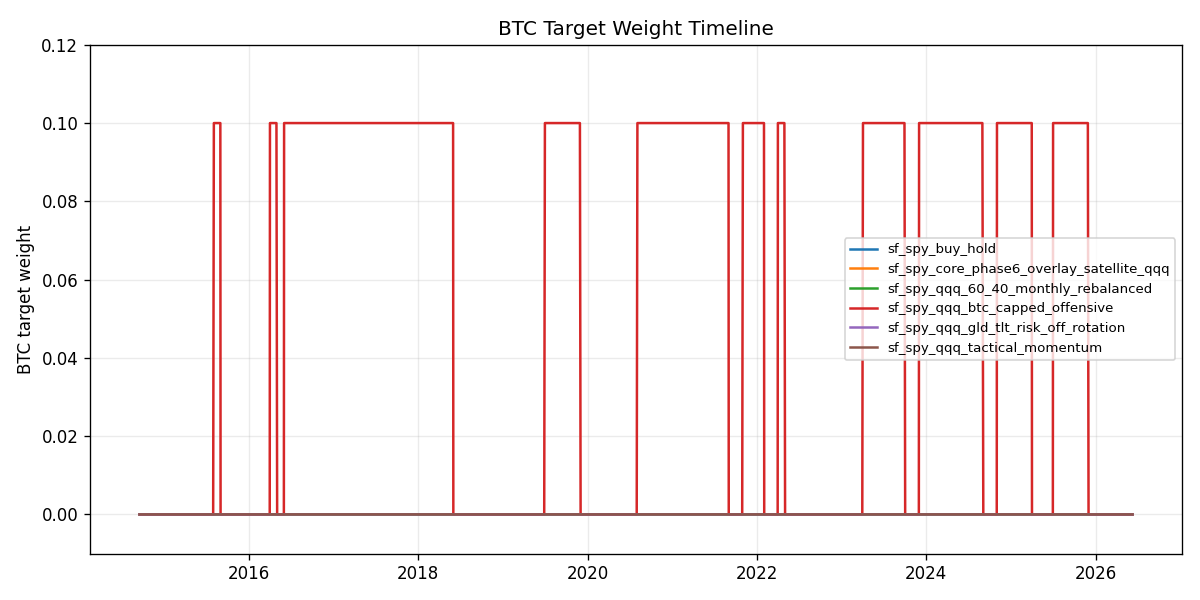

,diagnostic_available,btc_source_path,btc_rows,btc_min_date,btc_max_date,weekend_gap_count,average_friday_to_monday_return,median_friday_to_monday_return,worst_friday_to_monday_return,best_friday_to_monday_return,gaps_worse_than_minus_5_pct,gaps_worse_than_minus_10_pct,strict_common_date_caveat,non_monday_next_available_count,blocking_reason
0,True,data\fresh\processed\BTC-USD.parquet,4283,2014-09-17,2026-06-08,612,0.7207,0.4208,-22.6807,22.5129,59,15,Strategy Factory returns use strict ETF-tradin...,0,NaN


In [54]:
display(Image(filename=str(chart_dir / "btc_weight_timeline.png")))
btc_gap


## Watchlist Interpretation

- Clean growth watchlist: SPY/QQQ 60/40.
- Baseline-linked growth watchlist: Phase6-style SPY overlay plus QQQ satellite.
- High-growth/high-caveat watchlist: SPY/QQQ/BTC capped offensive.


In [55]:
if missing_watchlist_display_cols:
    print(
        "Optional watchlist display columns unavailable; showing NA placeholders:",
        missing_watchlist_display_cols,
    )
    print("Available Phase 17C watchlist columns:", list(watchlist.columns))

print("Canonical rolling 3Y beat-rate field:", ROLLING_3Y_BEAT_RATE_FIELD)
watchlist_enriched[WATCHLIST_DISPLAY_COLUMNS]


Canonical rolling 3Y beat-rate field: rolling_3y_candidate_beats_spy_pct


,candidate_id,watchlist_role,low_friction_cagr_pct,realistic_stress_cagr_pct,max_drawdown_pct,rolling_3y_candidate_beats_spy_pct,worst_3y_active_cagr,median_3y_active_cagr,latest_3y_active_cagr,btc_cap_dependency_flag,promotion_allowed,paper_watchlist_only
0,sf_spy_core_phase6_overlay_satellite_qqq,baseline_linked_growth_watchlist,16.01,15.99,-31.40,93.7,-0.45,2.27,2.18,False,False,True
1,sf_spy_qqq_60_40_monthly_rebalanced,clean_growth_watchlist,16.01,15.99,-31.40,93.7,-0.45,2.27,2.18,False,False,True
2,sf_spy_qqq_btc_capped_offensive,high_growth_high_caveat_watchlist,20.05,19.81,-31.44,93.11,-2.02,5.98,3.46,True,False,True


## Current Paper Relevance

Phase 16 paper preview currently represents only the Phase6 SPY overlay baseline.
The 60/40 and BTC Strategy Factory candidates are research watchlist candidates and
are not represented in active paper order preview files.


## Conclusion

Target-weight changes are signal/allocation changes. Drift-based rebalance trades are
estimated implementation trades. Neither are broker fills.

No candidate is promoted. There is no live trading, no real money, and no broker/API
execution. The next operational step is watchlist paper-preview integration or recurring
signal hardening, not live deployment.
